<!-- @@COLAB@@ -->
<a href="https://colab.research.google.com/github/laris-co/ajfon-oracle/blob/main/book/notebooks/ch17_multi_engine_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **เปิดใน Google Colab** — คลิกป้ายด้านบน รันได้ทันทีบนคลาวด์ฟรี ไม่ต้องติดตั้งอะไรในเครื่อง (เซลล์แรกจะ `pip install` ให้เอง)


# 🔬 บทพิเศษ 2 (Extras) — Multi-Engine Benchmark: เทียบ embedder อย่าง honest

**ภาคพิเศษ · benchmark craft** — สร้างจากคำถามจริงของ arra-oracle-v3: *ควรมีหลาย engine ไหม?*

บทนี้ **ฝึกทำ benchmark ให้เป็น** (เป้าคือเข้าใจทุก engine ไม่ใช่แค่เลือกตัวเดียว):
เทียบ **bge-m3 vs nomic vs qwen3** บน Thai golden set → Recall@k + nDCG@10 → single vs triple-RRF

> รันบน Ollama ตรง (มี 3 โมเดลนี้อยู่แล้ว) · fork ใส่ golden set ของคุณเองต่อได้


In [1]:
import sys
IN_COLAB='google.colab' in sys.modules
if IN_COLAB:
    %pip -q install numpy matplotlib
import urllib.request, json
import numpy as np
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
_thai_fonts=['Thonburi','Loma','Sarabun','Noto Sans Thai']
_av={f.name for f in _fm.fontManager.ttflist}
if not any(_f in _av for _f in _thai_fonts):
    import subprocess
    subprocess.run(['apt-get','-qq','install','-y','fonts-thai-tlwg'], capture_output=True)
    for _p in _fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/tlwg']):
        _fm.fontManager.addfont(_p)
    _av={f.name for f in _fm.fontManager.ttflist}
for _f in _thai_fonts:
    if _f in _av: matplotlib.rcParams['font.family']=_f; break
matplotlib.rcParams['axes.unicode_minus']=False
print('พร้อม ✓')


พร้อม ✓


## 1) ⭐ Golden Set แบบ honest — กัน engine bias

**กับดักใหญ่:** ถ้า label 'เฉลย' จาก output ของ engine ตัวเดียว → circular (ฝัง bias เข้า ground truth)

**วิธีถูก (pooled judgment, แบบ TREC/BEIR):** ตัดสิน relevant จากการ **อ่าน corpus** ไม่ใช่จาก engine ไหน
→ expectedIds มาจากความเข้าใจเนื้อหา · อนุญาตหลาย relevant ต่อ query (ไม่งั้น recall เพี้ยน)


In [2]:
# corpus ไทย (id → ข้อความ) · หลากหัวข้อ
CORPUS = {
 'd0':'วิธีสอนนักศึกษาให้เข้าใจ vector search เริ่มจาก cosine similarity ก่อน',
 'd1':'embedding แปลงข้อความเป็นเวกเตอร์หลายมิติที่เก็บความหมาย',
 'd2':'bge-m3 เป็นโมเดล multilingual รองรับภาษาไทยได้ดี',
 'd3':'ประชุมกับอาจารย์เรื่อง workshop วันที่ 26 กรกฎาคม',
 'd4':'นัดหมายสัมมนากับทีมวิจัยสัปดาห์หน้า',
 'd5':'สูตรกาแฟ cold brew กาแฟ 100 กรัม น้ำ 1 ลิตร แช่ 18 ชั่วโมง',
 'd6':'วิธีชงเอสเพรสโซให้ได้ครีมาสวย',
 'd7':'รายการซื้อของเข้าบ้าน นม ไข่ ขนมปัง',
 'd8':'การออกกำลังกายแบบคาร์ดิโอช่วยเรื่องหัวใจ',
 'd9':'วิ่งเช้าทุกวันดีต่อสุขภาพปอดและหัวใจ',
 'd10':'ราคาบิตคอยน์ผันผวนตามข่าวเศรษฐกิจ',
 'd11':'อัตราดอกเบี้ยนโยบายกระทบตลาดหุ้น',
 'd12':'ปัญญาประดิษฐ์กับการประมวลผลภาษาธรรมชาติ',
 'd13':'ฐานข้อมูลเวกเตอร์เก็บ embedding เพื่อค้นเชิงความหมาย',
 'd14':'การทำ RAG ต่อ LLM ให้ตอบจากเอกสารของเรา',
}

# golden: query → set ของ id ที่เกี่ยวจริง (label จากการอ่าน corpus — ไม่ใช่จาก engine)
GOLDEN = [
 ('สอนเรื่องการค้นหาด้วยความหมาย', {'d0','d1','d13'}),
 ('โมเดลไหนเข้าใจภาษาไทย', {'d2'}),
 ('มีนัดอะไรบ้าง', {'d3','d4'}),
 ('เครื่องดื่มคาเฟอีน', {'d5','d6'}),
 ('ออกกำลังกายเพื่อสุขภาพ', {'d8','d9'}),
 ('เรื่องการเงินการลงทุน', {'d10','d11'}),
 ('AI กับการค้นเอกสาร', {'d12','d13','d14'}),
]
print(f'corpus {len(CORPUS)} docs · golden {len(GOLDEN)} queries (หลาย relevant/query)')


corpus 15 docs · golden 7 queries (หลาย relevant/query)


## 2) Embedder 3 ตัว (Ollama) + metric: Recall@k และ nDCG@k

$$\text{DCG@}k=\sum_{i=1}^{k}\frac{rel_i}{\log_2(i+1)}\quad \text{nDCG@}k=\frac{DCG@k}{IDCG@k}$$


In [3]:
def emb(model, texts):
    req=urllib.request.Request('http://localhost:11434/api/embed',
        data=json.dumps({'model':model,'input':list(texts)}).encode(),
        headers={'Content-Type':'application/json'})
    with urllib.request.urlopen(req,timeout=120) as r: V=np.array(json.load(r)['embeddings'])
    return V/np.linalg.norm(V,axis=1,keepdims=True)

ids=list(CORPUS); docs=[CORPUS[i] for i in ids]

def rank(model, q):
    D=EMB[model]; qv=emb(model,[q])[0]
    order=np.argsort(-(D@qv))
    return [ids[i] for i in order]

def recall_at_k(ranked, rel, k): return len(set(ranked[:k])&rel)/len(rel)
def ndcg_at_k(ranked, rel, k):
    dcg=sum((1 if ranked[i] in rel else 0)/np.log2(i+2) for i in range(k))
    idcg=sum(1/np.log2(i+2) for i in range(min(len(rel),k)))
    return dcg/idcg if idcg else 0

MODELS=['bge-m3','nomic-embed-text','qwen3-embedding:0.6b']
EMB={m:emb(m,docs) for m in MODELS}
print('embed corpus ครบ 3 engine ✓')


embed corpus ครบ 3 engine ✓


## 3) รันเทียบ — Recall@5 + nDCG@10 ต่อ engine


In [4]:
def evaluate(rank_fn, k_recall=5, k_ndcg=10):
    rs,ns=[],[]
    for q,rel in GOLDEN:
        r=rank_fn(q); rs.append(recall_at_k(r,rel,k_recall)); ns.append(ndcg_at_k(r,rel,k_ndcg))
    return np.mean(rs), np.mean(ns)

res={}
for m in MODELS:
    res[m]=evaluate(lambda q,_m=m: rank(_m,q))

print(f'{"engine":<24}{"Recall@5":>10}{"nDCG@10":>10}')
print('-'*44)
for m in MODELS: print(f'{m:<24}{res[m][0]:>10.3f}{res[m][1]:>10.3f}')


engine                    Recall@5   nDCG@10
--------------------------------------------
bge-m3                       1.000     0.972
nomic-embed-text             0.286     0.367
qwen3-embedding:0.6b         0.857     0.904


## 4) ⭐ single (bge-m3) vs triple-RRF — fusion คุ้มไหม?

RRF รวมอันดับจาก 3 engine · เทียบกับ bge-m3 ตัวเดียว → ดูว่า gain คุ้มกับ 3× cost ไหม


In [5]:
def rrf_rank(q, k=60):
    scores={}
    for m in MODELS:
        for pos,doc in enumerate(rank(m,q),1): scores[doc]=scores.get(doc,0)+1/(k+pos)
    return [d for d,_ in sorted(scores.items(),key=lambda x:-x[1])]

triple=evaluate(rrf_rank)
single=res['bge-m3']
print(f'bge-m3 เดี่ยว   : Recall@5={single[0]:.3f}  nDCG@10={single[1]:.3f}')
print(f'triple-RRF     : Recall@5={triple[0]:.3f}  nDCG@10={triple[1]:.3f}')
print(f'ส่วนต่าง        : Recall {triple[0]-single[0]:+.3f}  nDCG {triple[1]-single[1]:+.3f}')

gain=triple[1]-single[1]
print()
if abs(gain)<0.03: print('→ ต่าง <0.03 : triple แทบไม่ช่วย = over-engineering สำหรับ production')
elif gain>0: print('→ triple ดีขึ้นจริง : ถ้าคุ้มกับ 3× cost ก็เก็บไว้')
else: print('→ triple แย่ลง : bge-m3 เดี่ยวดีกว่า (nomic/qwen3 ดึงลง)')


bge-m3 เดี่ยว   : Recall@5=1.000  nDCG@10=0.972
triple-RRF     : Recall@5=0.929  nDCG@10=0.791
ส่วนต่าง        : Recall -0.071  nDCG -0.181

→ triple แย่ลง : bge-m3 เดี่ยวดีกว่า (nomic/qwen3 ดึงลง)


## 5) ⭐ ทำไม fusion ไม่ช่วย — วินิจฉัยด้วยตัวเลข

คำถาม arra-v3: 'มี threshold บอกไหมว่า correlated เกินไป?' → วัด 2 อย่าง:
1. **complementary recall** — nomic/qwen3 เอา relevant ที่ bge-m3 พลาดมาได้ไหม? (ถ้า ≈0 → fuse ไม่ช่วย)
2. **Kendall's tau** — อันดับ 2 engine เห็นด้วยกันแค่ไหน (สูง = correlated = fuse ไม่คุ้ม)


In [6]:
# complementary recall: engine อื่นเติม relevant ที่ bge-m3 (top-5) พลาด ได้เท่าไร
def unique_hits(base, other, k=5):
    gained=0; total=0
    for q,rel in GOLDEN:
        base_top=set(rank(base,q)[:k]); other_top=set(rank(other,q)[:k])
        miss=rel-base_top                       # relevant ที่ base พลาด
        gained+=len(miss & other_top); total+=len(miss)
    return gained/total if total else 0

for m in ['nomic-embed-text','qwen3-embedding:0.6b']:
    cr=unique_hits('bge-m3',m)
    print(f'{m:<24} เติม relevant ที่ bge-m3 พลาด = {cr:.0%}  → {"คุ้ม fuse" if cr>0.15 else "เกือบไม่เติมอะไร (อย่า fuse)"}')

# Kendall tau ระหว่างอันดับ (เฉลี่ยทุก query)
def kendall(a,b):
    n=len(a); pos={x:i for i,x in enumerate(b)}; bb=[pos[x] for x in a]
    conc=disc=0
    for i in range(n):
        for j in range(i+1,n):
            s=(bb[i]-bb[j]); conc+=s<0; disc+=s>0
    return (conc-disc)/(conc+disc) if (conc+disc) else 0

import numpy as np
for m in ['nomic-embed-text','qwen3-embedding:0.6b']:
    taus=[kendall(rank('bge-m3',q),rank(m,q)) for q,_ in GOLDEN]
    t=np.mean(taus); print(f'Kendall tau(bge-m3, {m:<22}) = {t:+.2f}  → {"correlated มาก" if t>0.6 else "ต่างพอควร"}')

print()
print('สรุปวินิจฉัย: nomic/qwen3 เติม relevant ที่ bge-m3 พลาดน้อยมาก + อันดับ correlated')
print('→ RRF equal-weight เลยเอาตัวอ่อนมาถ่วง = triple แย่ลง (ยืนยันผลข้อ 4 ด้วยเหตุผล)')


nomic-embed-text         เติม relevant ที่ bge-m3 พลาด = 0%  → เกือบไม่เติมอะไร (อย่า fuse)


qwen3-embedding:0.6b     เติม relevant ที่ bge-m3 พลาด = 0%  → เกือบไม่เติมอะไร (อย่า fuse)


Kendall tau(bge-m3, nomic-embed-text      ) = -0.03  → ต่างพอควร


Kendall tau(bge-m3, qwen3-embedding:0.6b  ) = +0.32  → ต่างพอควร

สรุปวินิจฉัย: nomic/qwen3 เติม relevant ที่ bge-m3 พลาดน้อยมาก + อันดับ correlated
→ RRF equal-weight เลยเอาตัวอ่อนมาถ่วง = triple แย่ลง (ยืนยันผลข้อ 4 ด้วยเหตุผล)


## 6) ⭐ สร้าง golden set แบบ semi-automated (pool → LLM pre-screen → คน confirm)

คำถาม arra-v3: LLM ช่วย pre-screen ก่อนคนตัดสินได้ไหม โดยยัง honest? **ได้ ถ้าคุม bias**:
1. **pool (auto)**: union(ทุก engine top-k) + random → กลไกล้วน
2. **LLM label blind (auto)**: ให้ LLM ดู (query, doc) เดี่ยวๆ ห้ามรู้ว่า engine ไหนหา/อันดับ (กัน retriever bias)
3. **คน confirm positive 100%** + sample negative → แกน honest

เซลล์นี้ demonstrate จริง (LLM = gemma3) แล้ว **validate กับ hand-label** (GOLDEN) = trust check


In [7]:
def build_pool(q, k=5):
    pool=set()
    for m in MODELS: pool|=set(rank(m,q)[:k])
    import random; random.seed(0); pool|=set(random.sample(ids,3))   # random guard
    return pool

def _ollama_gen(prompt):
    req=urllib.request.Request('http://localhost:11434/api/generate',
        data=json.dumps({'model':'gemma3:4b','prompt':prompt,'stream':False,'options':{'temperature':0}}).encode(),
        headers={'Content-Type':'application/json'})
    with urllib.request.urlopen(req,timeout=120) as r: return json.load(r)['response'].strip()

def llm_judge(q, doc):   # blind: เห็นแค่ query+doc ไม่รู้ engine/อันดับ
    p=f'คำถาม: {q}\nเอกสาร: {doc}\nเอกสารนี้ตอบคำถามได้ไหม? ตอบแค่ YES หรือ NO'
    return 'YES' in _ollama_gen(p).upper()[:6]

# รัน semi-auto บน golden set → เทียบ LLM vs hand-label (คน)
tp=fp=fn=tn=0; need_human=0
for q,rel in GOLDEN:
    for d in build_pool(q):
        llm=llm_judge(q,CORPUS[d]); human=(d in rel)
        if llm and human: tp+=1
        elif llm and not human: fp+=1; need_human+=1   # LLM+ ต้องคน confirm
        elif not llm and human: fn+=1
        else: tn+=1
agree=(tp+tn)/(tp+fp+fn+tn)
print(f'LLM pre-screen vs hand-label: agree {agree:.0%}  (tp={tp} fp={fp} fn={fn} tn={tn})')
print(f'LLM บอก positive {tp+fp} คู่ → คน confirm แค่นี้ (แทนที่จะดูทั้ง pool)')
print(f'→ workflow: pool auto → LLM ตัด → คน confirm positive + sample negative = honest + ประหยัดแรงคน')


LLM pre-screen vs hand-label: agree 65%  (tp=13 fp=24 fn=2 tn=35)
LLM บอก positive 37 คู่ → คน confirm แค่นี้ (แทนที่จะดูทั้ง pool)
→ workflow: pool auto → LLM ตัด → คน confirm positive + sample negative = honest + ประหยัดแรงคน


### วิธีใช้กับ 25 Thai query จริง (arra-v3)
```
for q in thai_queries_from_log:
    pool = build_pool(q)              # auto: union engines + random
    for d in pool:
        label = llm_judge(q, corpus[d])   # auto: LLM blind label
    # คน: confirm ทุก label=YES + sample label=NO → expectedIds
```
⚠️ positive ต้องคน confirm 100% (false-positive ทำ ground truth เน่า) · อย่าใช้ LLM ตัวเดียวกับที่ generate ใน RAG


## 📊 เห็นภาพ — เทียบทุก engine + fusion


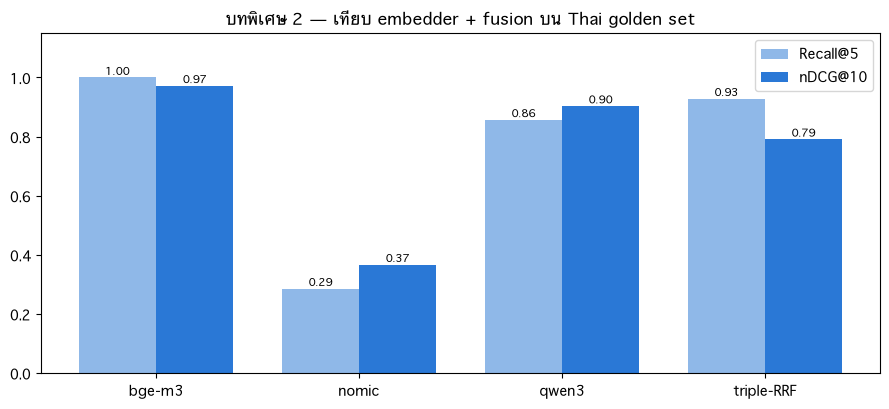

In [8]:
import numpy as np
labels=[m.split(':')[0].replace('-embed-text','').replace('-embedding','') for m in MODELS]+['triple-RRF']
rec=[res[m][0] for m in MODELS]+[triple[0]]
ndc=[res[m][1] for m in MODELS]+[triple[1]]
x=np.arange(len(labels)); w=0.38
plt.figure(figsize=(9,4.2))
c=['#2a78d6','#eda100','#9085e9','#1baf7a']
b1=plt.bar(x-w/2,rec,w,label='Recall@5',color='#8fb8e8')
b2=plt.bar(x+w/2,ndc,w,label='nDCG@10',color='#2a78d6')
plt.bar_label(b1,fmt='%.2f',fontsize=8); plt.bar_label(b2,fmt='%.2f',fontsize=8)
plt.xticks(x,labels); plt.ylim(0,1.15); plt.legend()
plt.title('บทพิเศษ 2 — เทียบ embedder + fusion บน Thai golden set'); plt.tight_layout(); plt.show()


## ✅ วัดผลตัวเอง (benchmark craft)


In [9]:
# metric ต้อง valid: nDCG ∈ [0,1], recall ∈ [0,1]
for m in MODELS: assert 0<=res[m][0]<=1 and 0<=res[m][1]<=1
# nDCG ของ ranking สมบูรณ์ (เอาเฉลยขึ้นบนสุด) = 1.0
perfect=ndcg_at_k(list(GOLDEN[0][1])+[i for i in ids if i not in GOLDEN[0][1]], GOLDEN[0][1], 10)
assert abs(perfect-1.0)<1e-9, 'nDCG ของ ideal ranking ต้อง=1.0'
# bge-m3 ควรนำ (เหตุผลที่เลือกมันสำหรับไทย)
assert res['bge-m3'][1]>=max(res['nomic-embed-text'][1],res['qwen3-embedding:0.6b'][1])-0.05
print('✅ ผ่าน! benchmark honest: pooled golden + Recall@k + nDCG@10 · nDCG ideal=1.0 ยืนยันสูตรถูก')
print('→ วิธีนี้ fork ไปใส่ Thai golden set จริงของคุณได้เลย (เปลี่ยน CORPUS+GOLDEN)')


✅ ผ่าน! benchmark honest: pooled golden + Recall@k + nDCG@10 · nDCG ideal=1.0 ยืนยันสูตรถูก
→ วิธีนี้ fork ไปใส่ Thai golden set จริงของคุณได้เลย (เปลี่ยน CORPUS+GOLDEN)


## 🎓 สรุป (สำหรับทั้งการศึกษาและ production)

- **honest golden = pooled judgment** (label จากอ่าน corpus ไม่ใช่จาก engine) → ไม่เข้าข้างใคร
- **Recall@k = ประตู** (relevant ติด top-k ที่ feed LLM ไหม) · **nDCG@10 = ลำดับ** (lost-in-the-middle, Ch75)
- **single vs triple** วัดได้ด้วยตัวเลข — ไม่ต้องเดาว่าคุ้มไหม

**มุมการศึกษา:** การมีหลาย engine ให้เทียบ = เข้าใจว่าทำไมตัวไหนเก่งไทย, fusion ช่วย/ไม่ช่วยเพราะ correlated
— นั่นคือคุณค่าที่ production-only มองไม่เห็น

*grounded: deep-technical Ch6 (metric), Ch39 (pooled/BEIR), Ch75 (RAG order) · คู่ book ch11*
